# 03 — Graph Analysis (axe Structure)

**Owner** : **Bachirou Konaté**

Étude comparative communautés PRD §N2.2 — **CRITIQUE pour le jury**.

## Algos évalués

1. **Louvain** (`python-louvain` + Neo4j GDS)
2. **Label Propagation** (`networkx`)
3. **Leiden** (`igraph`)

## Métriques

- Modularité par algo
- Stabilité (variation entre runs sur seed différentes)
- Runtime
- Inspection qualitative top 5 communautés (cohérence sémantique)

## Plus

- PageRank → top compétences-pivot (top 20)
- Génération JSON pour la page dashboard `/graph` (`react-force-graph-2d`)

## Section du rapport L5 alimentée

§4.2 Communautés comparées + §3.4 Pipeline Structure Mining.


In [1]:
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from collections import Counter
from matplotlib.patches import Patch

from skillnav.pipelines.structure_mining.graph_builder import build_graph
from skillnav.pipelines.structure_mining.pagerank import compute_pagerank
from skillnav.pipelines.structure_mining.communities import (
    compute_all_communities,
    compute_louvain,
    compute_leiden,
    compute_label_propagation,
)

Path("../data/exports").mkdir(parents=True, exist_ok=True)
print("Setup OK — dossier data/exports/ prêt")

Setup OK — dossier data/exports/ prêt


In [ ]:
t0 = time.perf_counter()
skill_graph, nx_graph = build_graph()
elapsed_build = time.perf_counter() - t0

print(f"build_graph()              : {elapsed_build:.2f}s")  # execution time
print(f"Offres chargées            : {skill_graph.job_count:,}")
print(f"Compétences uniques        : {skill_graph.metrics.node_count:,}")
print(f"Arêtes CO_OCCURS           : {skill_graph.metrics.edge_count:,}")

build_graph()              : 56.28s
Offres chargées            : 3,468
Compétences uniques        : 3,937
Arêtes CO_OCCURS           : 10,324


In [12]:
density = nx.density(nx_graph)
n_components = nx.number_connected_components(nx_graph)
avg_degree = sum(d for _, d in nx_graph.degree()) / nx_graph.number_of_nodes()

print("=== Métriques du graphe (§3.4 rapport) ===")
print(f"Nœuds (compétences uniques) : {nx_graph.number_of_nodes():>6,}")
print(f"Arêtes (co-occurrences)     : {nx_graph.number_of_edges():>6,}")
print(f"Densité                     : {density:>10.4f}")
print(f"Composantes connexes        : {n_components:>6}")
print(f"Degré moyen                 : {avg_degree:>10.2f}")

top10 = sorted(skill_graph.nodes_skills, key=lambda s: s.occurrence_count, reverse=True)[:10]
print("\nTop 10 par occurrence brute :")
for i, s in enumerate(top10, 1):
    print(f"  {i:2}. {s.name:<30} {s.occurrence_count:>5} offres  [{s.family.value}]")

=== Métriques du graphe (§3.4 rapport) ===
Nœuds (compétences uniques) :  3,937
Arêtes (co-occurrences)     : 10,324
Densité                     :     0.0013
Composantes connexes        :   2768
Degré moyen                 :       5.24

Top 10 par occurrence brute :
   1. prompt engineering              1150 offres  [Other]
   2. RAG                             1047 offres  [NLP]
   3. LangChain                        727 offres  [NLP]
   4. PyTorch                          707 offres  [Deep Learning]
   5. LLMs                             596 offres  [NLP]
   6. TensorFlow                       499 offres  [Deep Learning]
   7. LangGraph                        390 offres  [Other]
   8. fine-tuning                      289 offres  [Other]
   9. OpenAI API                       287 offres  [NLP]
  10. embeddings                       283 offres  [NLP]


Explication: 

- Arrêté: le nbre de lien entre des compétences qui existe dans au moin 2 fiches de posts

- Densité: C'est le rapport entre les arêtes qui existent réellement et toutes les arêtes qui pourraient exister théoriquement (chaque compétence reliée à toutes les autres).

Avec 3 937 nœuds, il pourrait y avoir ~7,7 millions d'arêtes possibles. Il n'en existe que 10 324, soit 0,13%. C'est normal et attendu : Python ne co-occure pas avec toutes les 3 936 autres compétences — seulement avec celles de son écosystème.

- Composantes connexes : 2 768
C'est la métrique la plus surprenante. Une composante connexe = un groupe de nœuds qui se "touchent" entre eux mais sont totalement isolés du reste du graphe.

2 768 composantes sur 3 937 nœuds signifie que la majorité des nœuds sont des îlots isolés — des compétences très rares ou très spécialisées qui ne co-occurrent qu'avec une ou deux autres compétences, sans pont vers le graphe principal.

-Degré moyen : 5.24
En moyenne, chaque compétence est reliée à 5 autres. Mais cette moyenne cache une distribution très inégale : Python est probablement relié à 200+ compétences, tandis qu'une compétence rare est reliée à 2-3 seulement.



## 1. PageRank — Compétences-pivot

Alpha = 0.85 (valeur Google). Un score élevé = compétence co-présente avec beaucoup d'autres compétences importantes.
Alimente §4.1 du rapport.

**Explication:** 

Ce que PageRank mesure précisément
Ce n'est pas juste "combien d'autres compétences accompagnent Python dans une offre", c'est "combien d'autres compétences importantes accompagnent Python".

La différence avec l'occurrence brute :

Occurrence brute — Python apparaît dans 2 100 offres sur 3 468. Elle est fréquente.

PageRank — Quand Python apparaît, est-ce qu'il co-occure avec des compétences qui sont elles-mêmes très connectées ? Oui : TensorFlow, PyTorch, SQL, Pandas, Scikit-learn, Docker... qui sont elles-mêmes très connectées à d'autres. Python hérite donc de leur importance.

Un exemple concret pour fixer l'idée
Imaginons deux compétences avec le même nombre d'occurrences brutes :


Python     → co-occure avec TensorFlow, PyTorch, SQL, Spark, Docker, Kafka...
             (compétences très demandées, elles-mêmes très connectées)

Excel      → co-occure avec PowerPoint, Word, Access...
             (compétences peu connectées au reste du graphe IA/DS)
             

In [4]:
t0 = time.perf_counter()
skill_graph = compute_pagerank(nx_graph, skill_graph)
elapsed_pr = time.perf_counter() - t0

print(f"PageRank (alpha=0.85) : {elapsed_pr:.3f}s\n")
print(f"{'#':<4} {'Compétence':<30} {'Score':>12}  Famille")
print("-" * 62)
for i, entry in enumerate(skill_graph.metrics.pagerank_top_20, 1):
    node = next((s for s in skill_graph.nodes_skills if s.name == entry.skill_name), None)
    family = node.family.value if node else "?"
    print(f"{i:<4} {entry.skill_name:<30} {entry.score:>12.6f}  {family}")

PageRank (alpha=0.85) : 3.145s

#    Compétence                            Score  Famille
--------------------------------------------------------------
1    prompt engineering                 0.047307  Other
2    RAG                                0.040913  NLP
3    LangChain                          0.028794  NLP
4    PyTorch                            0.025795  Deep Learning
5    TensorFlow                         0.018366  Deep Learning
6    LLMs                               0.018272  NLP
7    LangGraph                          0.015932  Other
8    fine-tuning                        0.010923  Other
9    scikit-learn                       0.010852  Statistics
10   embeddings                         0.009782  NLP
11   LlamaIndex                         0.009732  NLP
12   OpenAI API                         0.009573  NLP
13   CrewAI                             0.007319  Other
14   AI agents                          0.006742  Other
15   Deep Learning                      0.006597  Deep

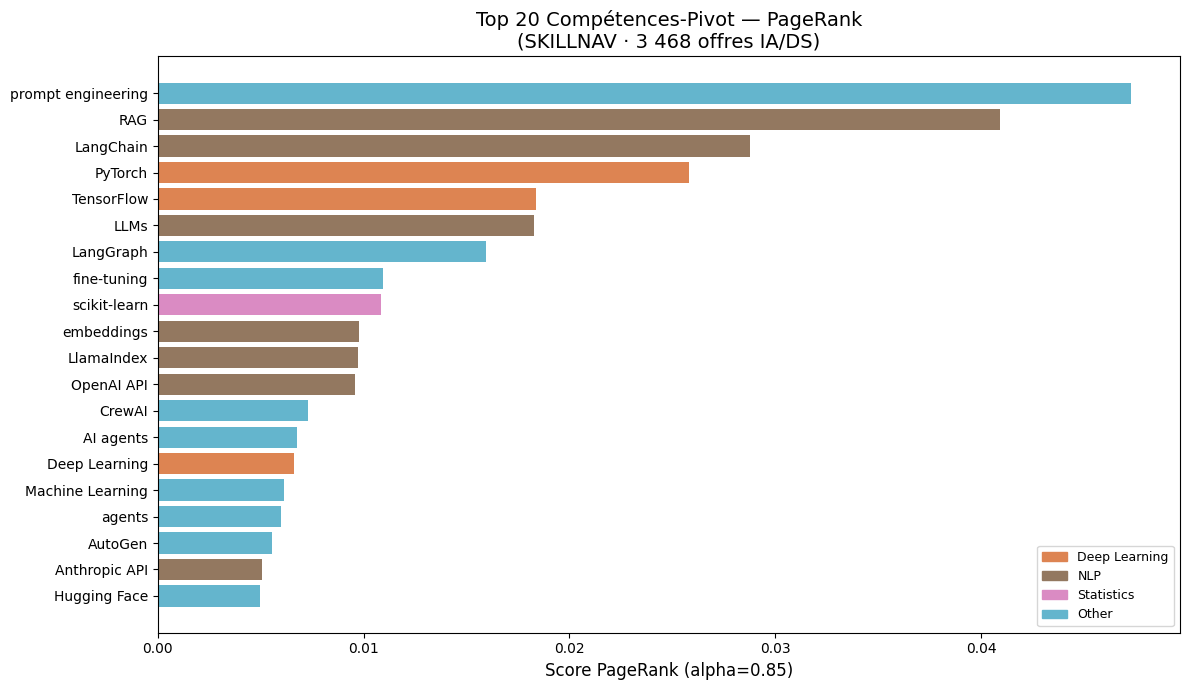

Sauvegardé : data/exports/pagerank_top20.png


In [15]:
FAMILY_COLORS = {
    "Agents AI":        "#2A9D8F",
    "GenAI":            "#6A4C93",
    "Programming":      "#4C72B0",
    "Deep Learning":    "#DD8452",
    "MLOps":            "#55A868",
    "Data Engineering": "#C44E52",
    "Machine Learning": "#F9844A",
    "Databases":        "#8172B2",
    "NLP":              "#937860",
    "Statistics":       "#DA8BC3",
    "Cloud":            "#8C8C8C",
    "Computer Vision":  "#CCB974",
    "BI & Analytics":   "#F4D35E",
    "Other":            "#64B5CD",
}

top20 = skill_graph.metrics.pagerank_top_20
names  = [e.skill_name for e in top20]
scores = [e.score for e in top20]
colors = [
    FAMILY_COLORS.get(
        next((s.family.value for s in skill_graph.nodes_skills if s.name == n), "Other"),
        "#64B5CD",
    )
    for n in names
]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(names[::-1], scores[::-1], color=colors[::-1])
ax.set_xlabel("Score PageRank (alpha=0.85)", fontsize=12)
ax.set_title(
    "Top 20 Compétences-Pivot — PageRank\n(SKILLNAV · 3 468 offres IA/DS)",
    fontsize=14,
)
ax.tick_params(axis="y", labelsize=10)

seen_families = {
    next((s.family.value for s in skill_graph.nodes_skills if s.name == n), "Other")
    for n in names
}
legend_handles = [
    Patch(color=FAMILY_COLORS[f], label=f)
    for f in FAMILY_COLORS if f in seen_families
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("../data/exports/pagerank_top20.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegardé : data/exports/pagerank_top20.png")

## 2. Détection de communautés — étude comparative (§4.2 rapport)

Trois algorithmes comparés sur la même donnée : **Louvain**, **Leiden**, **Label Propagation**.
Métrique : modularité Q ([-1, 1], plus élevé = meilleures communautés).

In [6]:
import copy

# Exécution des 3 algos séparément pour mesurer le temps
sg_leiden = copy.deepcopy(skill_graph)
t0 = time.perf_counter()
sg_leiden, leiden_q = compute_leiden(nx_graph, sg_leiden)
t_leiden = time.perf_counter() - t0
leiden_count = len({s.community_id for s in sg_leiden.nodes_skills if s.community_id >= 0})

sg_lp = copy.deepcopy(skill_graph)
t0 = time.perf_counter()
sg_lp, lp_q = compute_label_propagation(nx_graph, sg_lp)
t_lp = time.perf_counter() - t0
lp_count = len({s.community_id for s in sg_lp.nodes_skills if s.community_id >= 0})

t0 = time.perf_counter()
skill_graph, louvain_q = compute_louvain(nx_graph, skill_graph)
t_louvain = time.perf_counter() - t0
louvain_count = len({s.community_id for s in skill_graph.nodes_skills if s.community_id >= 0})

# Recalcule best_method sur le skill_graph principal
skill_graph, metrics = compute_all_communities(nx_graph, skill_graph)

print("=== Étude comparative — Communautés (§4.2 rapport) ===\n")
print(f"{'Algorithme':<22} {'Modularité Q':>14} {'Communautés':>13} {'Temps (s)':>10}")
print("-" * 63)
print(f"{'Louvain':<22} {louvain_q:>14.4f} {louvain_count:>13} {t_louvain:>10.3f}")
print(f"{'Leiden':<22} {leiden_q:>14.4f} {leiden_count:>13} {t_leiden:>10.3f}")
print(f"{'Label Propagation':<22} {lp_q:>14.4f} {lp_count:>13} {t_lp:>10.3f}")
print(f"\nMeilleur algorithme : {metrics.best_community_method}  (Q le plus élevé)")

=== Étude comparative — Communautés (§4.2 rapport) ===

Algorithme               Modularité Q   Communautés  Temps (s)
---------------------------------------------------------------
Louvain                        0.2953          2781      0.496
Leiden                         0.2981          2785      0.232
Label Propagation              0.1476          2784      0.205

Meilleur algorithme : leiden  (Q le plus élevé)


In [7]:
# Stabilité Label Propagation — 5 runs, seeds différents
print("=== Stabilité Label Propagation (5 runs, seeds 0-4) ===")
lp_mods = []
for seed in range(5):
    comms = list(nx.community.asyn_lpa_communities(nx_graph, weight="weight", seed=seed))
    q = float(nx.community.modularity(nx_graph, comms, weight="weight"))
    lp_mods.append(q)
    print(f"  seed={seed} : Q = {q:.4f}  ({len(comms)} communautés)")

print(f"\n  Moyenne    : {np.mean(lp_mods):.4f}")
print(f"  Écart-type : {np.std(lp_mods):.4f}")
print(f"\nLouvain et Leiden sont déterministes (std = 0).")

=== Stabilité Label Propagation (5 runs, seeds 0-4) ===
  seed=0 : Q = 0.1486  (2786 communautés)
  seed=1 : Q = 0.1486  (2784 communautés)
  seed=2 : Q = 0.1494  (2785 communautés)
  seed=3 : Q = 0.1484  (2785 communautés)
  seed=4 : Q = 0.1485  (2785 communautés)

  Moyenne    : 0.1487
  Écart-type : 0.0004

Louvain et Leiden sont déterministes (std = 0).


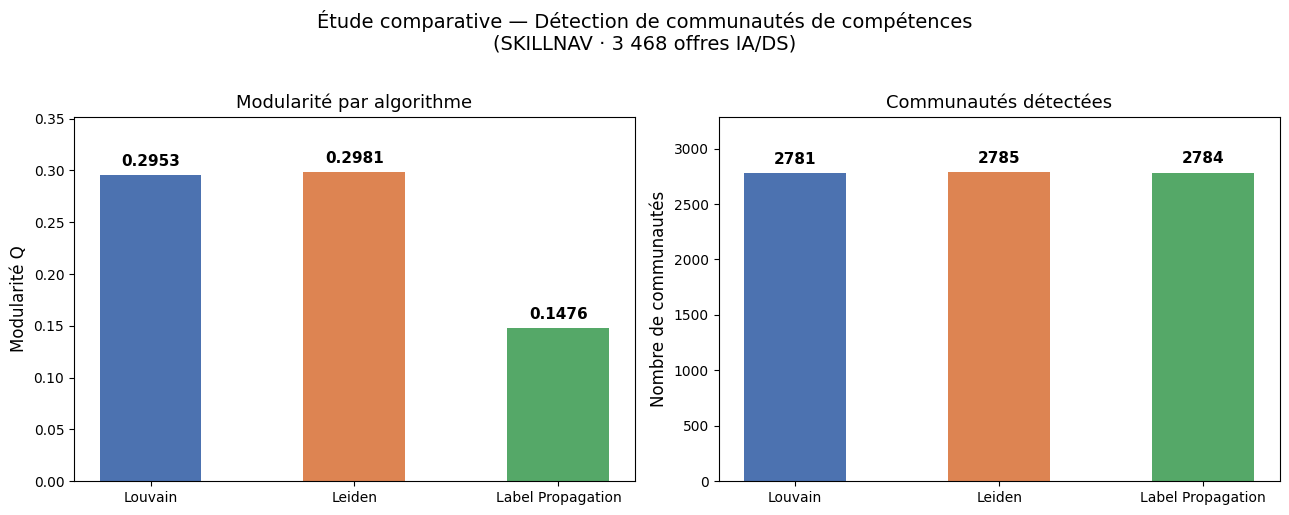

Sauvegardé : data/exports/community_comparison.png


In [8]:
# Graphique comparatif : modularité + nombre de communautés
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

algos      = ["Louvain", "Leiden", "Label Propagation"]
q_values   = [louvain_q, leiden_q, lp_q]
comm_counts = [louvain_count, leiden_count, lp_count]
bar_colors  = ["#4C72B0", "#DD8452", "#55A868"]

for ax, values, ylabel, title in [
    (axes[0], q_values,    "Modularité Q",          "Modularité par algorithme"),
    (axes[1], comm_counts, "Nombre de communautés", "Communautés détectées"),
]:
    bars = ax.bar(algos, values, color=bar_colors, width=0.5)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13)
    for bar, v in zip(bars, values):
        label = f"{v:.4f}" if isinstance(v, float) else str(v)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.02,
            label, ha="center", va="bottom", fontsize=11, fontweight="bold",
        )
    ax.set_ylim(0, max(values) * 1.18)

plt.suptitle(
    "Étude comparative — Détection de communautés de compétences\n(SKILLNAV · 3 468 offres IA/DS)",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.savefig("../data/exports/community_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegardé : data/exports/community_comparison.png")

In [9]:
# Inspection qualitative : top 5 communautés Louvain (§4.2 rapport)
community_members: dict[int, list] = {}
for s in skill_graph.nodes_skills:
    community_members.setdefault(s.community_id, []).append(s)

top5 = sorted(community_members.items(), key=lambda x: len(x[1]), reverse=True)[:5]

print("=== Top 5 communautés Louvain — cohérence sémantique ===\n")
for rank, (cid, members) in enumerate(top5, 1):
    members_sorted = sorted(members, key=lambda s: s.pagerank_score, reverse=True)
    top_skills     = [s.name for s in members_sorted[:10]]
    families       = Counter(s.family.value for s in members)
    dominant       = families.most_common(1)[0][0]
    coverage       = families.most_common(1)[0][1] / len(members) * 100

    print(f"Communauté #{rank}  (id={cid}) — {len(members)} compétences — Famille dominante: {dominant} ({coverage:.0f}%)")
    print(f"  Top 10 : {', '.join(top_skills)}")
    print()

=== Top 5 communautés Louvain — cohérence sémantique ===

Communauté #1  (id=30) — 620 compétences — Famille dominante: Other (74%)
  Top 10 : prompt engineering, RAG, LangChain, LLMs, LangGraph, fine-tuning, embeddings, LlamaIndex, OpenAI API, CrewAI

Communauté #2  (id=122) — 259 compétences — Famille dominante: Other (73%)
  Top 10 : PyTorch, TensorFlow, scikit-learn, Deep Learning, Generative AI, Reinforcement Learning, Transformers, Keras, NLP, CUDA

Communauté #3  (id=208) — 144 compétences — Famille dominante: Other (89%)
  Top 10 : Cursor, GitHub Copilot, Llama, Claude, Claude Code, Gemini, n8n, GPT, Mistral, Salesforce

Communauté #4  (id=375) — 78 compétences — Famille dominante: Other (49%)
  Top 10 : Machine Learning, Python, SQL, GCP, Power BI, R, Statistics, Azure, Spark, Tableau

Communauté #5  (id=49) — 19 compétences — Famille dominante: Other (89%)
  Top 10 : Solution architecture, stakeholder management, concurrency, hallucination detection, memory management, prompt

## 3. Export JSON — Dashboard `/graph` (react-force-graph-2d)

Top 200 nœuds par PageRank + arêtes correspondantes. Format attendu par `web/src/app/graph/page.tsx`.

In [10]:
import json

top_nodes     = sorted(skill_graph.nodes_skills, key=lambda s: s.pagerank_score, reverse=True)[:200]
top_node_ids  = {s.name for s in top_nodes}

nodes_json = [
    {
        "id":        s.name,
        "pagerank":  round(s.pagerank_score, 6),
        "community": s.community_id,
        "family":    s.family.value,
        "count":     s.occurrence_count,
    }
    for s in top_nodes
]

links_json = [
    {"source": e.skill_a, "target": e.skill_b, "weight": e.weight}
    for e in skill_graph.edges_co_occurs
    if e.skill_a in top_node_ids and e.skill_b in top_node_ids
]

export_path = Path("../data/exports/graph_vis.json")
export_path.write_text(
    json.dumps({"nodes": nodes_json, "links": links_json}, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"Export dashboard : {len(nodes_json)} nœuds | {len(links_json)} liens")
print(f"Fichier          : data/exports/graph_vis.json ({export_path.stat().st_size // 1024} KB)")

Export dashboard : 200 nœuds | 4603 liens
Fichier          : data/exports/graph_vis.json (470 KB)
